# 0. Dependencies

In [1]:
# External imports
import tacoreader
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch
from skimage.measure.entropy import shannon_entropy
from utils.files_info import get_files_info
import segmentation_model.modules.segmentator as seg 
import time
import segmentation_model.modules.classify_hard as ch
import pandas as pd

# 1. Get CLOUDSEN12+ data

## 1.1 Load Data using Tacoreader library

In [2]:
print(tacoreader.__version__) 

# Remotely load the Cloud-Optimized Dataset 
dataset = tacoreader.load("tacofoundation:cloudsen12-l1c")
dataset_extra = tacoreader.load("tacofoundation:cloudsen12-extra")

0.5.6


In [4]:
# https://huggingface.co/datasets/tacofoundation/cloudsen12/tree/main and download CLOUDSEN12+ metadata files.
# WAY FASTER THAN REMOTE LOADING.
dataset = tacoreader.load([
    "dataset/cloudsen12-l1c.0000.part.taco", 
    "dataset/cloudsen12-l1c.0001.part.taco", 
    "dataset/cloudsen12-l1c.0002.part.taco",
    "dataset/cloudsen12-l1c.0003.part.taco", 
    "dataset/cloudsen12-l1c.0004.part.taco",])

dataset_extra = tacoreader.load([
    "dataset/cloudsen12-extra.0000.part.taco", 
    "dataset/cloudsen12-extra.0001.part.taco", 
    "dataset/cloudsen12-extra.0002.part.taco",])


In [5]:
# Read s2_ids.txt and sort it
with open('s2_ids.txt', 'r') as f:
    s2_ids = f.read().splitlines()

s2_ids = sorted(s2_ids)

len(s2_ids)

2200

In [6]:
def load_label_data(sample_idx):
    s2_l2a = dataset.read(sample_idx).read(0)
    s2_label = dataset_extra.read(sample_idx).read(1)
    try:
        with rasterio.open(s2_l2a) as s2_l1c_src, rasterio.open(s2_label) as lbl:
            s2_l2a = s2_l1c_src.read([4, 3, 2])
            s2_label_data = lbl.read()
    except rasterio.errors.RasterioIOError as e:
        logging.error(f"Error opening files: {e}")
        s2_l2a, s2_label_data = None, None

    return s2_l2a, s2_label_data

def load_extra_labels(dataset_extra, sample_idx):
    extra_labels = [
        dataset_extra.read(sample_idx).read(i) for i in range(12)
    ]
    return extra_labels

def load_multiple_files(files):
    data = {}
    for label, file in files.items():
        with rasterio.open(file) as f:
            data[label] = f.read().squeeze()
    return data

def compute_confusion_matrix(outpath, true_labels, predicted_labels, class_names, model_title="Model"):
    """
    Compute and plot the confusion matrix for segmentation classes.

    Parameters:
    - true_labels: np.array, ground truth labels
    - predicted_labels: np.array, predicted labels
    - class_names: list of str, names of the classes
    - model_title: str, title of the model to be displayed on the plot

    Returns:
    - cm: np.array, confusion matrix
    """
    cm = confusion_matrix(true_labels, predicted_labels, labels=range(len(class_names)))
    plt.figure(figsize=(20, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted', labelpad=20, fontsize=12)
    plt.ylabel('True', labelpad=20, fontsize=12)
    plt.title(f'Confusion Matrix - {model_title}', fontsize=18)
    plt.savefig(f'{outpath}/{model_title}_confusion_matrix.png')
    return cm

In [7]:
# Define class names and number of classes
class_names4 = ['Land', 'Thick Cloud', 'Thin Cloud', 'Shadow']
num_classes = len(class_names4)

def map_scoreplus(scoreplus_mask, nir_band, cloud_threshold=0.3, shadow_nir_threshold=0.2):
    # Normalize ScorePlus and NIR
    norm_mask = scoreplus_mask / 10000.0
    norm_nir = nir_band / 10000.0

    # Start with all pixels as clear (1)
    output_mask = np.ones_like(scoreplus_mask, dtype=np.uint8)

    # Define occluded pixels: where cloud score is low
    occluded = norm_mask < cloud_threshold

    # Among occluded pixels, define shadow where NIR is dark
    shadow_pixels = occluded & (norm_nir < shadow_nir_threshold)
    output_mask[shadow_pixels] = 3  # shadow

    # Remaining occluded (not shadow) = cloud
    cloud_pixels = occluded & ~shadow_pixels
    output_mask[cloud_pixels] = 1  # cloud

    land_pixels = ~occluded
    output_mask[land_pixels] = 0  # land/clear
    return output_mask


def map_s2cloudless(
    s2cloudless_mask,
    nir_band,
    cloud_threshold=0.3,
    shadow_nir_threshold=0.2,
    scale=10000
):
    import s2cloudless
    s2cloudless_cprob = s2cloudless.S2PixelCloudDetector(threshold=cloud_threshold)
    norm_prob = s2cloudless_mask / 100.0
    # s2cloudless expects a 3D array: (batch, height, width)
    norm_prob = norm_prob[np.newaxis, ...]
    s2cloudless_mask = s2cloudless_cprob.get_mask_from_prob(norm_prob).squeeze()
    
    # Start with all pixels as clear (0)
    output_mask = np.zeros_like(s2cloudless_mask, dtype=np.uint8)
    
    # Define occluded pixels: where cloud probability is high
    occluded = s2cloudless_mask == 1

    # Among non-occluded pixels, define shadow where NIR is dark
    shadow_pixels = ~occluded & (nir_band < (shadow_nir_threshold * scale))
    output_mask[shadow_pixels] = 3  # shadow
    
    # Occluded pixels = cloud
    cloud_pixels = occluded
    output_mask[cloud_pixels] = 1  # cloud
    
    # Remaining pixels stay clear (0)
    return output_mask

## 1.2 Add Cloud Mask layers into the images

In [8]:
SCOREPLUS_THRESHOLD = 0.9
S2CLOUDLESS_THRESHOLD = 0.9
SHADOW_NIR_THRESHOLD = 0.1

In [9]:
for sample_idx in range(len(s2_ids)):
    img_df = dataset[dataset["tortilla:id"] == s2_ids[sample_idx].split('.')[0]]
    if img_df.empty:
        print(f"Warning: No entry found for {s2_ids[sample_idx]}")
        continue
    img_df = img_df.read(0)
    s2_l1c = img_df.read(0)
    with rasterio.open(s2_l1c) as src:
        image = src.read()

    extra_df = dataset_extra[dataset_extra["tortilla:id"] == s2_ids[sample_idx].split('.')[0]].read(0)
    extra_labels_files = {
        'cloudmask_s2cloudless': extra_df.read(6),
        "cloudmask_cloudscore_cs_v1": extra_df.read(7),
    }

    extra_labels_data = load_multiple_files(extra_labels_files)

    s2_label_data = img_df.read(1)
    with rasterio.open(s2_label_data) as s2_label_src:
        s2_label_data = s2_label_src.read()

    roi_number = f"{s2_ids[sample_idx].split('_')[0]}_{s2_ids[sample_idx].split('_')[1][1:]}"
    s2_id = f"{s2_ids[sample_idx].split('_')[3]}_{s2_ids[sample_idx].split('_')[4]}_{s2_ids[sample_idx].split('_')[5]}".split('.')[0]

    # Load scoreplus results
    scoreplus_data = extra_labels_data["cloudmask_cloudscore_cs_v1"]
    scoreplus_mask = map_scoreplus(scoreplus_data, nir_band=image[7], cloud_threshold=SCOREPLUS_THRESHOLD, shadow_nir_threshold=SHADOW_NIR_THRESHOLD)

    # Load s2cloudless results
    s2cloudless_data = extra_labels_data["cloudmask_s2cloudless"]
    s2cloudless_mask = map_s2cloudless(s2cloudless_data, nir_band=image[7], cloud_threshold=S2CLOUDLESS_THRESHOLD, shadow_nir_threshold=SHADOW_NIR_THRESHOLD)

    # Add extra labels as bands to the image
    image = np.concatenate([
        image, 
        scoreplus_mask[np.newaxis, ...],   # 13
        s2cloudless_mask[np.newaxis, ...], # 14
        s2_label_data[0][np.newaxis, ...], # 15
    ], axis=0)

    # Define the output path for the new dataset
    output_path = os.path.join(f"data/input", f"img_{sample_idx}.tif")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    # Save the new dataset using rasterio
    with rasterio.open(
        output_path,
        mode='w',
        driver='GTiff',
        height=image.shape[1],
        width=image.shape[2],
        count=image.shape[0],
        dtype=image.dtype,
        crs=src.crs,
        transform=src.transform
    ) as dst:
        dst.write(image)

    print(f"Processed {s2_ids[sample_idx]} and saved to {output_path}")
    print(f"Image shape: {image.shape}")


Processed ROI_00001__20190212T142031_20190212T143214_T19FDF and saved to data/input/img_0.tif
Image shape: (16, 512, 512)
Processed ROI_00001__20190304T142031_20190304T142654_T19FDF and saved to data/input/img_1.tif
Image shape: (16, 512, 512)
Processed ROI_00001__20190316T141049_20190316T142437_T19FDF and saved to data/input/img_2.tif
Image shape: (16, 512, 512)
Processed ROI_00001__20190525T141059_20190525T142053_T19FDF and saved to data/input/img_3.tif
Image shape: (16, 512, 512)
Processed ROI_00001__20200308T141731_20200308T143551_T19FDF and saved to data/input/img_4.tif
Image shape: (16, 512, 512)
Processed ROI_00002__20190116T142751_20190116T143701_T19GDN and saved to data/input/img_5.tif
Image shape: (16, 512, 512)
Processed ROI_00002__20190602T142041_20190602T142839_T19GDN and saved to data/input/img_6.tif
Image shape: (16, 512, 512)
Processed ROI_00002__20200217T141651_20200217T142551_T19GDN and saved to data/input/img_7.tif
Image shape: (16, 512, 512)
Processed ROI_00002__202

# 2. Segmentation - Repeat for each mask


In [12]:
SCOREPLUS_INDEX = 13
S2CLOUDLESS_INDEX = 14
MANUALLY_LABELED_INDEX = 15
dataset_path = "data/input" # FIX THIS PATH TO YOUR PREFERENCE IN MY CASE I ADDED THE PROCESSED IMAGES TO /threhold_data folder

In [7]:
def segment_th(input_path, overlay, cloudmask):
    masker = seg.load_sam()

    # Define CSV name depending on cloud mask
    if cloudmask == SCOREPLUS_INDEX:
        csv_name = f"objects_data_scoreplus_{SCOREPLUS_THRESHOLD}.csv"
    elif cloudmask == S2CLOUDLESS_INDEX:
        csv_name = f"objects_data_s2cloudless_{S2CLOUDLESS_THRESHOLD}.csv"
    else:
        csv_name = "objects_data_raw.csv"

    csv_path = os.path.join("data", csv_name)

    img_names = os.listdir(input_path)
    img_names.sort()

    tempo_inicial_total = time.time()

    # Load already processed images (resume feature)
    processed = set()
    if os.path.exists(csv_path):
        processed = set(pd.read_csv(csv_path)["img_name"])

    for img_name in img_names:
        if img_name in processed:
            print(f"Pulando {img_name} (já processada)")
            continue

        print(f'Iniciando: {img_name}')
        init_time = time.time()

        img_path = os.path.join(input_path, img_name)

        image, img_tif = seg.load_image_tif(img_path, 10000)

        if overlay:
            image = seg.overlay_predictions(image, img_tif[cloudmask])

        masks = seg.segment(image, masker)

        for obj in masks:
            CLASS = ch.hard_classify(img_tif, obj)
            obj['class'] = CLASS

        masks = [m for m in masks if m['class'] != 4]

        total_area = sum(obj['area'] for obj in masks)

        row = pd.DataFrame([{
            "img_name": img_name,
            "total_objects": len(masks),
            "total_area": total_area
        }])

        row.to_csv(
            csv_path,
            mode='a',
            header=not os.path.exists(csv_path),
            index=False
        )

        end_time = time.time()
        tempo_total = end_time - init_time
        print(f"Tempo de processamento da imagem {img_name}: {tempo_total:.2f} segundos")

    tempo_total = time.time() - tempo_inicial_total
    print(f"\nProcessamento finalizado!")
    print(f"Foram processadas {len(img_names)} imagens em: {tempo_total:.2f} segundos!")

In [ ]:
segment_th(dataset_path, overlay=True, cloudmask=S2CLOUDLESS_INDEX)
torch.cuda.empty_cache()

In [ ]:
segment_th(dataset_path, overlay=True, cloudmask=SCOREPLUS_INDEX)
torch.cuda.empty_cache()

# 3. Results

## s2cloudless

In [ ]:
SCOREPLUS_INDEX = 13
S2CLOUDLESS_INDEX = 14
MANUALLY_LABELED_INDEX = 15

dataset_path = "threshold_data"
raw_df = pd.read_csv(f"{dataset_path}/raw_data.csv")

thresholds = [round(0.1 * i, 1) for i in range(1, 10)]

merged_data_by_threshold = {}

for threshold in thresholds:
    masked_df = pd.read_csv(f"{dataset_path}/objects_data_s2cloudless_{threshold}.csv")

    if "img_name" in masked_df.columns:
        masked_df = masked_df.rename(columns={"img_name": "name"})
    elif "name" not in masked_df.columns:
        masked_df = masked_df.reset_index().rename(columns={"index": "name", "img_name": "name"})

    if "total_objects" in masked_df.columns:
        masked_df = masked_df.rename(columns={"total_objects": "masked_total_objects"})
    if "total_area" in masked_df.columns:
        masked_df = masked_df.rename(columns={"total_area": "masked_total_area"})

    if "name" not in masked_df.columns:
        raise ValueError(
            f"'name' column not found for threshold {threshold}. "
            f"Columns: {masked_df.columns.tolist()}"
        )

    merged_df = pd.merge(raw_df, masked_df, on="name", how="inner")

    merged_df["total_objects_diff"] = merged_df["masked_total_objects"] - merged_df["raw_total_objects"]
    merged_df["delta_no"] = np.where(
        merged_df["raw_total_objects"] != 0,
        merged_df["total_objects_diff"] / merged_df["raw_total_objects"] * 100,
        0
    )

    merged_data_by_threshold[threshold] = merged_df


In [27]:
img_path = f"data/input"
num_files, image_names = get_files_info(img_path)
sorted_image_names = sorted(image_names)
filtered_raw_df = raw_df.copy()

for i in range(num_files):
    image_name = sorted_image_names[i]
    src = rasterio.open(
        img_path + "/" + image_name,
        mode='r',
        driver='GTiff',
        count=None,
        crs='EPSG:4326',
        transform=None,
        dtype='float32', 
    )
    image_tif = src.read()
    image = np.moveaxis(image_tif[[3, 2, 1]], 0, -1) / 10000
 
    cloud_area = np.sum(image_tif[MANUALLY_LABELED_INDEX] == 1)
    cloud_percentage = round((cloud_area / (image_tif.shape[1] * image_tif.shape[2])) * 100, 2)

    for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        merged_data_by_threshold[threshold].loc[
            merged_data_by_threshold[threshold]['name'] == image_name, 'cloud_percentage'
        ] = cloud_percentage

    filtered_raw_df.loc[filtered_raw_df['name'] == image_name, 'cloud_percentage'] = cloud_percentage


Total number of files: 2200


In [ ]:
def overlay_predictions(image, prediction):
    # Create an overlay image
    overlay = image.copy()
    # Apply red color to mask pixels
    overlay[prediction == 1] = [255, 0, 0]  # Set red color for mask pixels
    return overlay

dataset_path = "threshold_data"
filtered_df = merged_data_by_threshold[S2CLOUDLESS_THRESHOLD][(merged_data_by_threshold[S2CLOUDLESS_THRESHOLD]['cloud_percentage'] > 10) & (merged_data_by_threshold[S2CLOUDLESS_THRESHOLD]['cloud_percentage'] < 90)]

img_names = filtered_df['name'].tolist()
print(len(img_names), "images to process")

# Define class names and number of classes
class_names4 = ['Land', 'Thick Cloud', 'Thin Cloud', 'Shadow']
num_classes = len(class_names4)


# Initialize empty confusion matrices and entropy accumulator
conf_matrices = {
    "scoreplus": np.zeros((num_classes, num_classes), dtype=np.uint64),
    "s2cloudless": np.zeros((num_classes, num_classes), dtype=np.uint64),
}

entropy_accumulator = {
    model: {'R': 0.0, 'G': 0.0, 'B': 0.0}
    for model in conf_matrices.keys()
}

# Process each file
for img_name in img_names:
    img_path = f"data/input/{img_name}"

    with rasterio.open(img_path) as src:
        img = src.read()
        
        rgb_original = img[[3, 2, 1]]  # Assuming bands are in BGR order
        rgb_original = (rgb_original / 10000 * 255).astype(np.uint8)
        rgb_original = np.transpose(rgb_original, (1, 2, 0))  # Change to HWC format

        y_true = img[MANUALLY_LABELED_INDEX].flatten()

        scoreplus = img[SCOREPLUS_INDEX]
        s2cloudless = img[S2CLOUDLESS_INDEX]

        # Prepare predictions for each model
        preds = {
            "scoreplus": scoreplus.flatten(),
            "s2cloudless": s2cloudless.flatten(),
        }

        for model, y_pred in preds.items():
            # Update confusion matrix
            if y_true.size > 0 and y_true.shape == y_pred.shape:
                cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
                conf_matrices[model] += cm.astype(np.uint64)
            
            # Reshape predictions to match RGB dimensions
            prediction = y_pred.reshape(src.height, src.width)
            
            masked_image = overlay_predictions(rgb_original, prediction)
            
            # Calculate entropy for each band
            for i, band in enumerate(['R', 'G', 'B']):
                entropy = shannon_entropy(masked_image[:, :, i])
                entropy_accumulator[model][band] += entropy


# Calculate mean entropies
mean_entropies = {
    model: {
        band: entropy_accumulator[model][band] / num_files
        for band in ['R', 'G', 'B']
    }
    for model in conf_matrices.keys()
}

for model, cm in conf_matrices.items():
    # Calculate metrics
    OA = np.trace(cm) / np.sum(cm)
    precision = np.diag(cm) / np.sum(cm, axis=0)
    recall = np.diag(cm) / np.sum(cm, axis=1)
    F1 = 2 * (precision * recall) / (precision + recall)
    IoU = np.diag(cm) / (np.sum(cm, axis=1) + np.sum(cm, axis=0) - np.diag(cm))
    
    df = pd.DataFrame({
        "Class": class_names4,
        "F1 Score": np.nan_to_num(F1),
        "IoU": np.nan_to_num(IoU)
    })
    df.loc[len(df)] = ["Overall Accuracy", np.nan_to_num(OA), ""]
    df.loc[len(df)] = ["Mean Entropy R", filtered_df['raw_R_entropy'].mean() - mean_entropies[model]['R'], ""]
    df.loc[len(df)] = ["Mean Entropy G", filtered_df['raw_G_entropy'].mean() - mean_entropies[model]['G'], ""]
    df.loc[len(df)] = ["Mean Entropy B", filtered_df['raw_B_entropy'].mean() - mean_entropies[model]['B'], ""]
    
    # Save to CSV
    df.to_csv(os.path.join(dataset_path, f"metrics_cm_{model}_{S2CLOUDLESS_THRESHOLD}.csv"), index=False)

1232 images to process


/tmp/ipykernel_30687/2779017916.py:81: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(cm) / np.sum(cm, axis=0)
/tmp/ipykernel_30687/2779017916.py:81: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(cm) / np.sum(cm, axis=0)


In [29]:
# Thresholds (assuming masked_data_1 corresponds to threshold 0.1, and so on)
thresholds = [round(0.1 * i, 1) for i in range(1, 10)]  # [0.1, 0.2, ..., 0.7]
metrics_th = {
}
dataset_path = "threshold_data"


for i, threshold in enumerate(thresholds, start=1):
    metrics = pd.read_csv(f"{dataset_path}/metrics_cm_s2cloudless_{threshold}.csv")
    metrics2 = pd.read_csv(f"{dataset_path}/metrics_cm_scoreplus_{threshold}.csv")
    
    metrics_th[threshold] = {
        "s2cloudless": metrics,
        "scoreplus": metrics2
    }
metrics_th

{0.1: {'s2cloudless':               Class  F1 Score       IoU
  0              Land  0.633012  0.463070
  1       Thick Cloud  0.700857  0.539477
  2        Thin Cloud  0.000000  0.000000
  3            Shadow  0.131627  0.070450
  4  Overall Accuracy  0.606364       NaN
  5    Mean Entropy R  8.537558       NaN
  6    Mean Entropy G  8.253594       NaN
  7    Mean Entropy B  8.043572       NaN,
  'scoreplus':               Class  F1 Score       IoU
  0              Land  0.599066  0.427619
  1       Thick Cloud  0.569466  0.398080
  2        Thin Cloud  0.000000  0.000000
  3            Shadow  0.000863  0.000432
  4  Overall Accuracy  0.522049       NaN
  5    Mean Entropy R  6.871651       NaN
  6    Mean Entropy G  6.538450       NaN
  7    Mean Entropy B  6.292361       NaN},
 0.2: {'s2cloudless':               Class  F1 Score       IoU
  0              Land  0.699097  0.537394
  1       Thick Cloud  0.753697  0.604746
  2        Thin Cloud  0.000000  0.000000
  3            Shado

## Scoreplus

In [30]:
dataset_path = "threshold_data"
raw_df = pd.read_csv(f"{dataset_path}/raw_data.csv")

# Thresholds (assuming masked_data_1 corresponds to threshold 0.1, and so on)
thresholds = [round(0.1 * i, 1) for i in range(1, 10)]  # [0.1, 0.2, ..., 0.7]

# Dictionary to store results
merged_data_by_threshold_scoreplus = {}

for i, threshold in enumerate(thresholds, start=1):
    masked_df = pd.read_csv(f"{dataset_path}/objects_data_scoreplus_{threshold}.csv", index_col=0)
    
    if "img_name" in masked_df.columns:
        masked_df = masked_df.rename(columns={"img_name": "name"})
    elif "name" not in masked_df.columns:
        masked_df = masked_df.reset_index().rename(columns={"index": "name", "img_name": "name"})

    if "total_objects" in masked_df.columns:
        masked_df = masked_df.rename(columns={"total_objects": "masked_total_objects"})
    if "total_area" in masked_df.columns:
        masked_df = masked_df.rename(columns={"total_area": "masked_total_area"})

    if "name" not in masked_df.columns:
        raise ValueError(
            f"'name' column not found for threshold {threshold}. "
            f"Columns: {masked_df.columns.tolist()}"
        )

    merged_df = pd.merge(raw_df, masked_df, on="name", how="inner")

    # Calculate total object difference and delta_no
    merged_df['total_objects_diff'] = merged_df['masked_total_objects'] - merged_df['raw_total_objects']
    merged_df['delta_no'] = np.where(
        merged_df['raw_total_objects'] != 0,
        merged_df['total_objects_diff'] / merged_df['raw_total_objects'] * 100,
        0
    )

    # Store in dictionary
    merged_data_by_threshold_scoreplus[threshold] = merged_df


In [31]:
img_path = f"data/input"
num_files, image_names = get_files_info(img_path)
sorted_image_names = sorted(image_names)
filtered_raw_df = raw_df.copy()

for i in range(num_files):
    image_name = sorted_image_names[i]
    src = rasterio.open(
        img_path + "/" + image_name,
        mode='r',
        driver='GTiff',
        count=None,
        crs='EPSG:4326',
        transform=None,
        dtype='float32', 
    )
    image_tif = src.read()
    image = np.moveaxis(image_tif[[3, 2, 1]], 0, -1) / 10000
    
    # CLOUD PERCENTAGE CALCULATION
    cloud_area = np.sum(image_tif[MANUALLY_LABELED_INDEX] == 1)
    cloud_percentage = round((cloud_area / (image_tif.shape[1] * image_tif.shape[2])) * 100, 2)

    for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        merged_data_by_threshold_scoreplus[threshold].loc[
            merged_data_by_threshold_scoreplus[threshold]['name'] == image_name, 'cloud_percentage'
        ] = cloud_percentage
    filtered_raw_df.loc[filtered_raw_df['name'] == image_name, 'cloud_percentage'] = cloud_percentage

filtered_raw_df = filtered_raw_df[(filtered_raw_df['cloud_percentage'] > 10) & (filtered_raw_df['cloud_percentage'] < 90)]
filtered_raw_df.to_csv(os.path.join(dataset_path, f"filtered_raw_df_threholds.csv"), index=False)

# After filter, how many images do we have?
print(len(filtered_raw_df), "images after filtering by cloud percentage")

Total number of files: 2200
1232 images after filtering by cloud percentage


## Plot

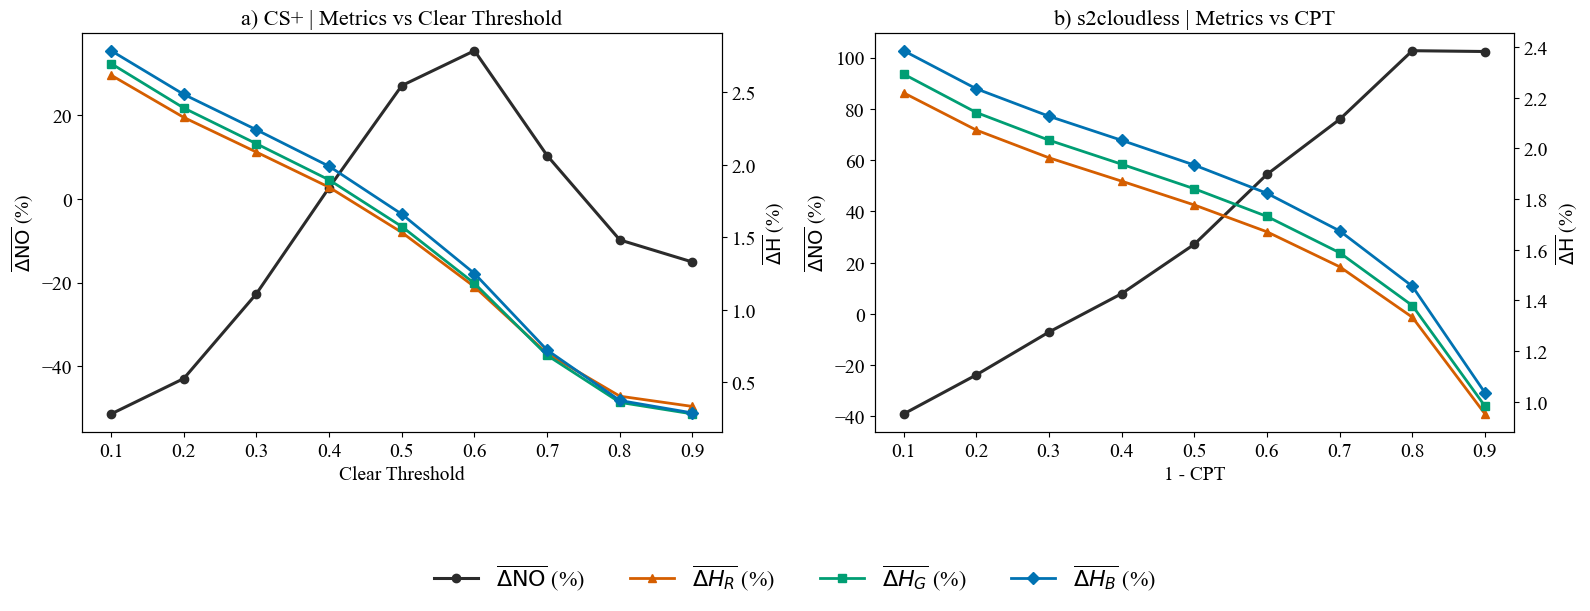

In [35]:
plt.rcParams['font.family'] = 'Times New Roman'

cloud_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
clear_thresholds = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
thresholds = cloud_thresholds

filtered_raw_df = filtered_raw_df[
    (filtered_raw_df['cloud_percentage'] > 10) &
    (filtered_raw_df['cloud_percentage'] < 90)
]

delta_no_values_scoreplus = [
    merged_data_by_threshold_scoreplus[t][
        (merged_data_by_threshold_scoreplus[t]['cloud_percentage'] > 10) &
        (merged_data_by_threshold_scoreplus[t]['cloud_percentage'] < 90)
    ]['delta_no'].mean()
    for t in cloud_thresholds
]

delta_no_values_s2cloudless = [
    merged_data_by_threshold[t][
        (merged_data_by_threshold[t]['cloud_percentage'] > 10) &
        (merged_data_by_threshold[t]['cloud_percentage'] < 90)
    ]['delta_no'].mean()
    for t in clear_thresholds
]

entropy_R_values_scoreplus = [
    filtered_raw_df['raw_R_entropy'].mean() -
    metrics_th[t]['scoreplus'][metrics_th[t]['scoreplus']['Class'] == 'Mean Entropy R'].values[0][1]
    for t in cloud_thresholds
]

entropy_G_values_scoreplus = [
    filtered_raw_df['raw_G_entropy'].mean() -
    metrics_th[t]['scoreplus'][metrics_th[t]['scoreplus']['Class'] == 'Mean Entropy G'].values[0][1]
    for t in cloud_thresholds
]

entropy_B_values_scoreplus = [
    filtered_raw_df['raw_B_entropy'].mean() -
    metrics_th[t]['scoreplus'][metrics_th[t]['scoreplus']['Class'] == 'Mean Entropy B'].values[0][1]
    for t in cloud_thresholds
]

entropy_R_values_s2cloudless = [
    filtered_raw_df['raw_R_entropy'].mean() -
    metrics_th[t]['s2cloudless'][metrics_th[t]['s2cloudless']['Class'] == 'Mean Entropy R'].values[0][1]
    for t in clear_thresholds
]

entropy_G_values_s2cloudless = [
    filtered_raw_df['raw_G_entropy'].mean() -
    metrics_th[t]['s2cloudless'][metrics_th[t]['s2cloudless']['Class'] == 'Mean Entropy G'].values[0][1]
    for t in clear_thresholds
]

entropy_B_values_s2cloudless = [
    filtered_raw_df['raw_B_entropy'].mean() -
    metrics_th[t]['s2cloudless'][metrics_th[t]['s2cloudless']['Class'] == 'Mean Entropy B'].values[0][1]
    for t in clear_thresholds
]

color_no = '#2B2B2B'   # dark neutral (ΔNO)
color_R  = '#D55E00'   # deep red (entropy R)
color_G  = '#009E73'   # teal green (entropy G)
color_B  = '#0072B2'   # muted blue (entropy B)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# ==========================================================
# Subplot 1 — CS+
# ==========================================================
ax1.set_title('a) CS+ | Metrics vs Clear Threshold', fontsize=16)
ax1.set_xlabel('Clear Threshold', fontsize=14)
ax1.set_ylabel(r'$\overline{\Delta \mathrm{NO}}$ (%)', fontsize=14)

line1a = ax1.plot(
    thresholds, delta_no_values_scoreplus,
    marker='o', linewidth=2.2,
    color=color_no,
    label=r'$\overline{\Delta \mathrm{NO}}$ (%)'
)

ax1.tick_params(axis='both', labelsize=14)

ax1b = ax1.twinx()
ax1b.set_ylabel(r'$\overline{\Delta \mathrm{H}}$ (%)', fontsize=14)

line2a_R = ax1b.plot(
    thresholds, entropy_R_values_scoreplus,
    marker='^', linewidth=2,
    color=color_R,
    label=r'$\overline{\Delta H_R}$ (%)'
)

line2a_G = ax1b.plot(
    thresholds, entropy_G_values_scoreplus,
    marker='s', linewidth=2,
    color=color_G,
    label=r'$\overline{\Delta H_G}$ (%)'
)

line2a_B = ax1b.plot(
    thresholds, entropy_B_values_scoreplus,
    marker='D', linewidth=2,
    color=color_B,
    label=r'$\overline{\Delta H_B}$ (%)'
)

ax1b.tick_params(axis='y', labelsize=14)

# ==========================================================
# Subplot 2 — s2cloudless
# ==========================================================
ax2.set_title('b) s2cloudless | Metrics vs CPT', fontsize=16)
ax2.set_xlabel('1 - CPT', fontsize=14)
ax2.set_ylabel(r'$\overline{\Delta \mathrm{NO}}$ (%)', fontsize=14)

line1b = ax2.plot(
    thresholds, delta_no_values_s2cloudless,
    marker='o', linewidth=2.2,
    color=color_no,
    label=r'$\overline{\Delta \mathrm{NO}}$ (%)'
)

ax2.tick_params(axis='both', labelsize=14)

ax2b = ax2.twinx()
ax2b.set_ylabel(r'$\overline{\Delta \mathrm{H}}$ (%)', fontsize=14)

line2b_R = ax2b.plot(
    thresholds, entropy_R_values_s2cloudless,
    marker='^', linewidth=2,
    color=color_R,
    label=r'$\overline{\Delta H_R}$ (%)'
)

line2b_G = ax2b.plot(
    thresholds, entropy_G_values_s2cloudless,
    marker='s', linewidth=2,
    color=color_G,
    label=r'$\overline{\Delta H_G}$ (%)'
)

line2b_B = ax2b.plot(
    thresholds, entropy_B_values_s2cloudless,
    marker='D', linewidth=2,
    color=color_B,
    label=r'$\overline{\Delta H_B}$ (%)'
)

ax2b.tick_params(axis='y', labelsize=14)

all_lines = line1a + line2a_R + line2a_G + line2a_B
labels = [l.get_label() for l in all_lines]

fig.legend(
    all_lines,
    labels,
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, -0.03),
    fontsize=16,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.27)
plt.savefig("MainFigure.png", dpi=300)
plt.show()